In [33]:
!pip install rdkit

In [34]:
from rdkit import Chem
print("RDKit OK")

RDKit OK


In [35]:
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, DataStructs

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import xgboost as xgb
import shap
import matplotlib.pyplot as plt

In [36]:
pip install chembl_webresource_client

In [37]:
from chembl_webresource_client.new_client import new_client
import pandas as pd

target = new_client.target
activity = new_client.activity

# Search XO target
targets = target.search("xanthine oxidase")
xo_target = targets[0]["target_chembl_id"]

print("XO Target ID:", xo_target)

# Fetch bioactivities
activities = activity.filter(
    target_chembl_id=xo_target,
    standard_type="IC50"
)

records = []
for a in activities:
    if a["standard_value"] and a["canonical_smiles"]:
        records.append([
            a["molecule_chembl_id"],
            a["canonical_smiles"],
            float(a["standard_value"]),
            a["standard_units"]
        ])

df = pd.DataFrame(records, columns=[
    "ChEMBL_ID","SMILES","IC50","Units"
])

# Keep micromolar data
df = df[df["Units"] == "nM"]
df = df[df["IC50"] <= 10000]

df.to_csv("xo_inhibitors_raw.csv", index=False)
print("Saved XO dataset:", df.shape)

XO Target ID: CHEMBL1929
Saved XO dataset: (609, 4)


In [38]:
activities = activity.filter(
    target_chembl_id=xo_target,
    standard_type="IC50"
)

In [39]:
records = []

for a in activities:
    if a["standard_value"] and a["canonical_smiles"]:
        records.append([
            a["molecule_chembl_id"],
            a["canonical_smiles"],
            float(a["standard_value"]),
            a["standard_units"]
        ])

df = pd.DataFrame(records, columns=[
    "ChEMBL_ID","SMILES","IC50","Units"
])

# Keep nM only
df = df[df["Units"] == "nM"]

# Convert to µM
df["IC50_uM"] = df["IC50"] / 1000

In [40]:
active_df = df[df["IC50_uM"] <= 10]
inactive_df = df[df["IC50_uM"] > 20]

In [41]:
final_df = pd.concat([active_df, inactive_df])
final_df.to_csv("xo_filtered_dataset.csv", index=False)

In [42]:
print("Active:", active_df.shape)
print("Inactive:", inactive_df.shape)

Active: (609, 5)
Inactive: (296, 5)


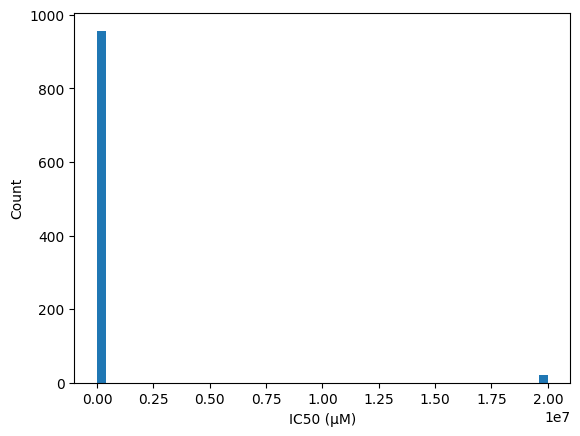

In [43]:
import matplotlib.pyplot as plt

plt.hist(df["IC50_uM"], bins=50)
plt.xlabel("IC50 (µM)")
plt.ylabel("Count")
plt.show()

In [44]:
import numpy as np

df = df[df["IC50_uM"] > 0]
df["pIC50"] = -np.log10(df["IC50_uM"] * 1e-6)

In [45]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd

def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.RingCount(mol),
        Descriptors.FractionCSP3(mol)
    ]

desc_names = [
    "MolWt","LogP","TPSA","HBD","HBA",
    "RotB","RingCount","FracCSP3"
]

desc_values = df["SMILES"].apply(calc_descriptors)
desc_df = pd.DataFrame(desc_values.tolist(), columns=desc_names)

df = pd.concat([df, desc_df], axis=1)
df.dropna(inplace=True)

In [46]:
from rdkit.Chem import AllChem, DataStructs
import numpy as np

def get_fp(smiles, bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=bits)
    arr = np.zeros((bits,))
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

fp_array = np.array(df["SMILES"].apply(get_fp).tolist())

[16:44:22] DEPRECATION WARNING: please use MorganGenerator
[16:44:22] DEPRECATION WARNING: please use MorganGenerator
[16:44:22] DEPRECATION WARNING: please use MorganGenerator
[16:44:22] DEPRECATION WARNING: please use MorganGenerator
[16:44:22] DEPRECATION WARNING: please use MorganGenerator
[16:44:22] DEPRECATION WARNING: please use MorganGenerator
[16:44:22] DEPRECATION WARNING: please use MorganGenerator
[16:44:22] DEPRECATION WARNING: please use MorganGenerator
[16:44:22] DEPRECATION WARNING: please use MorganGenerator
[16:44:22] DEPRECATION WARNING: please use MorganGenerator
[16:44:22] DEPRECATION WARNING: please use MorganGenerator
[16:44:22] DEPRECATION WARNING: please use MorganGenerator
[16:44:22] DEPRECATION WARNING: please use MorganGenerator
[16:44:22] DEPRECATION WARNING: please use MorganGenerator
[16:44:22] DEPRECATION WARNING: please use MorganGenerator
[16:44:22] DEPRECATION WARNING: please use MorganGenerator
[16:44:22] DEPRECATION WARNING: please use MorganGenerat

In [47]:
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import numpy as np

morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)

def get_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((2048,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

In [48]:
fp_array = np.array(df["SMILES"].apply(get_fp).tolist())

In [49]:
X_desc = df[desc_names].values
X = np.hstack((X_desc, fp_array))
y = df["pIC50"].values

print("Feature matrix:", X.shape)
print("Target:", y.shape)

Feature matrix: (950, 2056)
Target: (950,)


In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.8413248199892751
RMSE: 0.8578431343089609
MAE: 0.5831026960855785


In [52]:
from sklearn.model_selection import cross_val_score

cv = cross_val_score(rf, X, y, cv=5, scoring="r2")
print("CV R2 Mean:", cv.mean())
print("CV R2 Std:", cv.std())

CV R2 Mean: -0.2602577612424579
CV R2 Std: 0.6062376269174787


In [53]:
from sklearn.model_selection import cross_val_score

cv = cross_val_score(rf, X, y, cv=5, scoring="r2")
print("CV R2 Mean:", cv.mean())
print("CV R2 Std:", cv.std())

CV R2 Mean: -0.2602577612424579
CV R2 Std: 0.6062376269174787


In [54]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_test)

print("XGB R2:", r2_score(y_test, pred_xgb))
print("XGB RMSE:", np.sqrt(mean_squared_error(y_test, pred_xgb)))

XGB R2: 0.8097095002825576
XGB RMSE: 0.9394246101642328


In [55]:
import joblib
joblib.dump(rf, "xo_qsar_model.pkl")

['xo_qsar_model.pkl']

In [56]:
new_smiles = [
    "CC1=NC2=NC=NC=C2N1",
    "O=C(O)C1=CN=CN1"
]

def prepare_features(smiles_list):
    desc = [calc_descriptors(s) for s in smiles_list]
    fp = [get_fp(s) for s in smiles_list]
    return np.hstack((np.array(desc), np.array(fp)))

X_new = prepare_features(new_smiles)
pred = rf.predict(X_new)

for s,p in zip(new_smiles,pred):
    print(s,"Predicted pIC50:",round(p,2))

CC1=NC2=NC=NC=C2N1 Predicted pIC50: 4.42
O=C(O)C1=CN=CN1 Predicted pIC50: 5.03


William's Plot

In [58]:
X_train_mat = np.matrix(X_train)
H = X_train_mat * np.linalg.pinv(X_train_mat.T * X_train_mat) * X_train_mat.T
leverage = np.array(H.diagonal()).flatten()

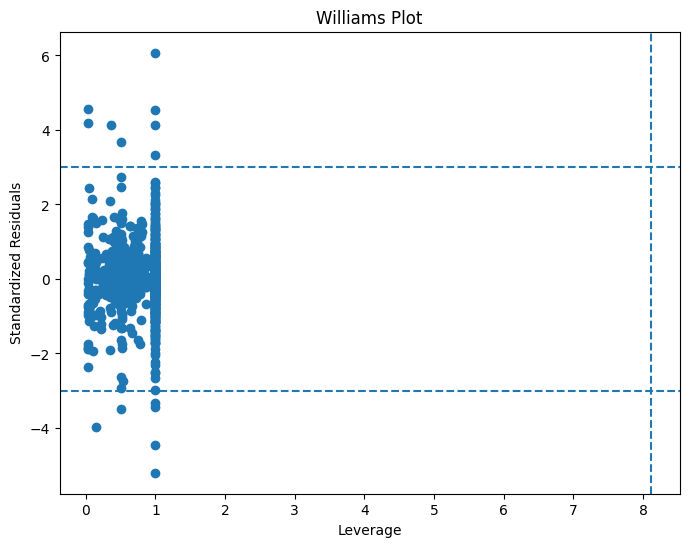

In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Leverage
X_train_mat = np.matrix(X_train)
H = X_train_mat * np.linalg.pinv(X_train_mat.T * X_train_mat) * X_train_mat.T
leverage = np.array(H.diagonal()).flatten()

# Standardized residuals
y_train_pred = rf.predict(X_train)
residuals = y_train - y_train_pred
std_residuals = residuals / np.std(residuals)

# Warning leverage
p = X_train.shape[1]
n = X_train.shape[0]
h_star = (3*(p+1))/n

# Plot
plt.figure(figsize=(8,6))
plt.scatter(leverage, std_residuals)
plt.axhline(3, linestyle='--')
plt.axhline(-3, linestyle='--')
plt.axvline(h_star, linestyle='--')
plt.xlabel("Leverage")
plt.ylabel("Standardized Residuals")
plt.title("Williams Plot")
plt.show()

SHAP Applicability

In [60]:
!pip install shap

In [61]:
import shap
import numpy as np

Create SHAP Explainer

In [62]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train)

Create global feature Importance

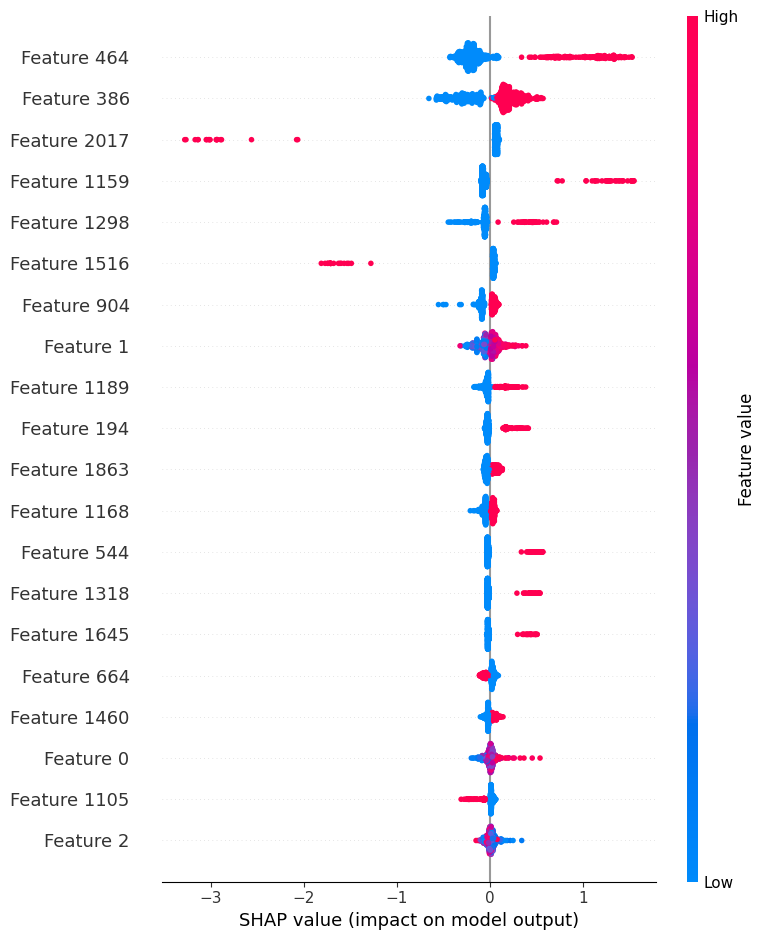

In [63]:
shap.summary_plot(shap_values, X_train)

Bar Plot (Top Contributing Features)

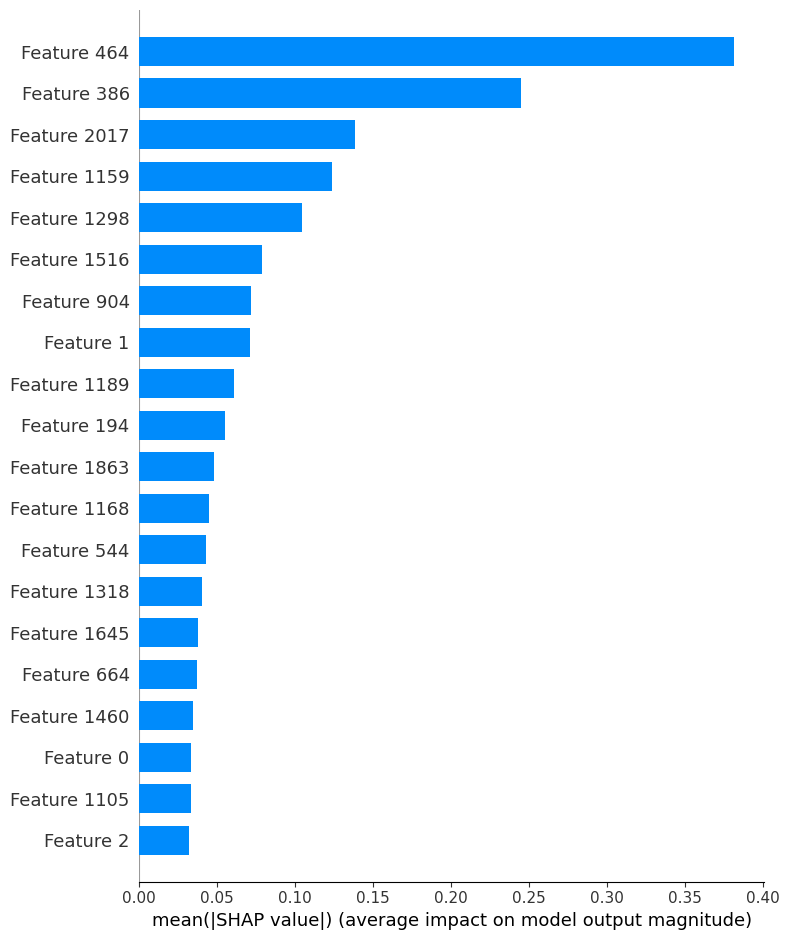

In [64]:
shap.summary_plot(shap_values, X_train, plot_type="bar")

Explain Individual Compound Prediction

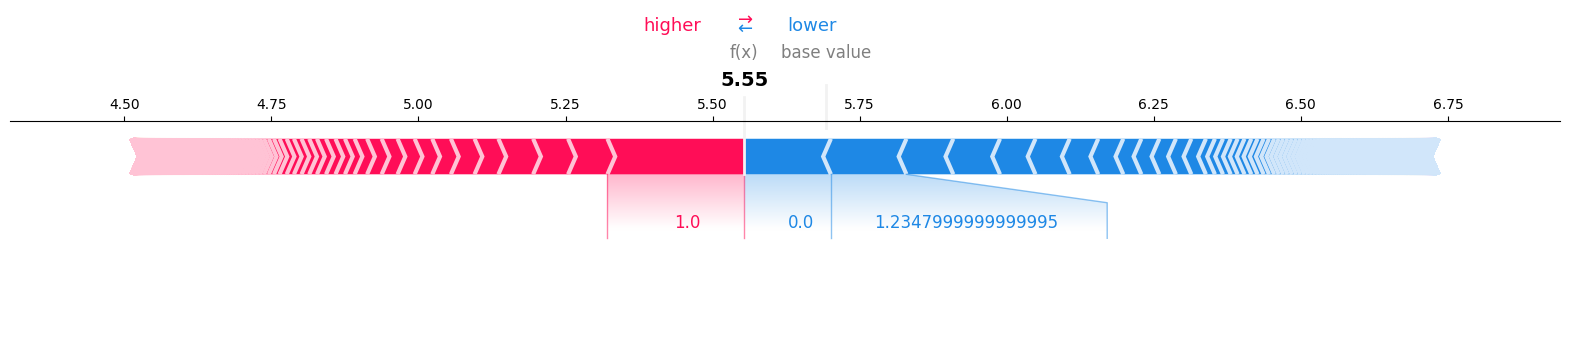

In [65]:
idx = 0
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_train[idx],
    matplotlib=True
)

Waterfall Plot (Cleaner for Papers)

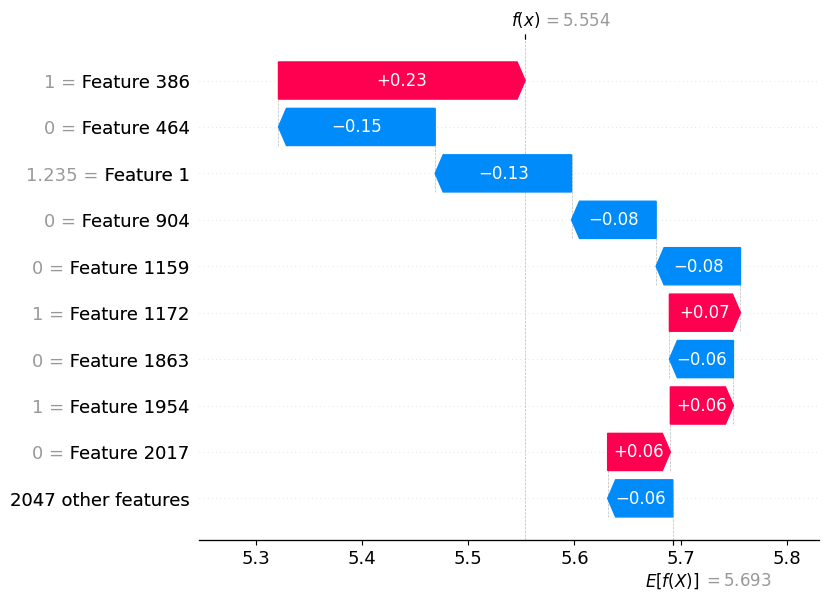

In [66]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_train[idx]
    )
)

Link SHAP to Chemistry (Critical)

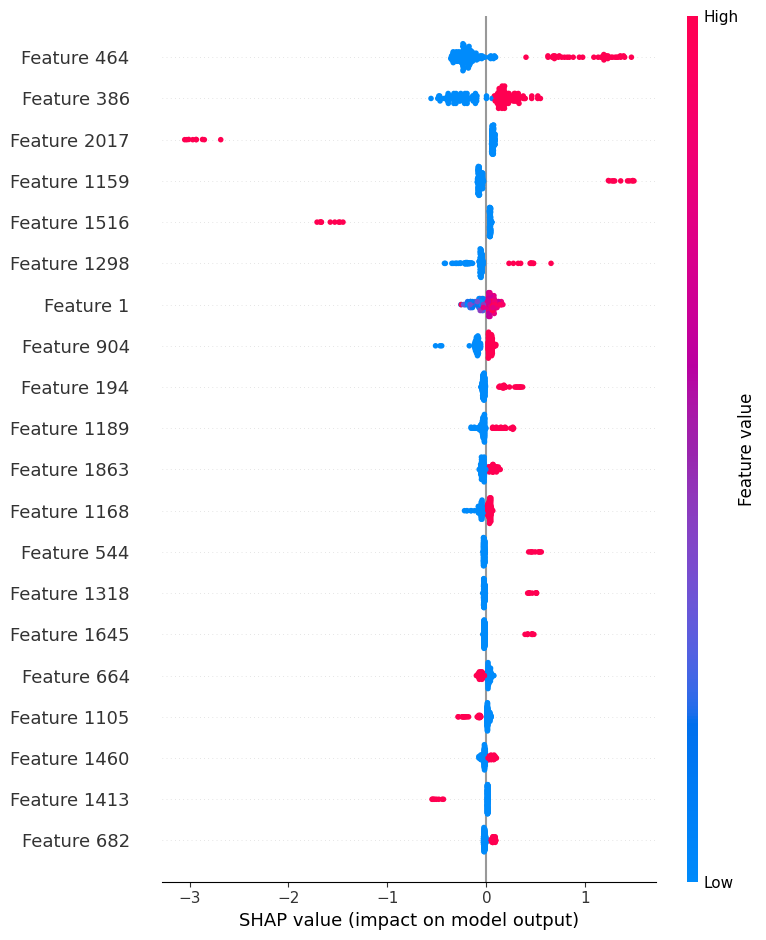

In [67]:
shap_values_test = explainer.shap_values(X_test)
shap.summary_plot(shap_values_test, X_test)

Docking-integrated QSAR